# 01 - EDA

Exploracao inicial do dataset HVFHV usando Spark SQL. Todas as transformacoes analiticas ficam em `spark.sql()`; pandas aparece apenas depois de agregacoes pequenas para visualizacao.

In [1]:
import sys
sys.path.insert(0, '/home/jovyan/work/notebooks')

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from _lib import build_spark, SEED, DATA_GLOB, LOOKUP_PATH

spark = build_spark('nyc-rideshare-eda')
sns.set_theme(style='whitegrid')

In [2]:
spark.read.parquet(DATA_GLOB).createOrReplaceTempView('trips_full')
(spark.read
    .option('header', True)
    .option('inferSchema', True)
    .csv(LOOKUP_PATH)
    .createOrReplaceTempView('taxi_zone_lookup'))

# Recorte temporal: Mar-Ago 2023 (6 meses). Dataset cobre Dez/2021-Ago/2023.
spark.sql("""
    CREATE OR REPLACE TEMPORARY VIEW trips_raw AS
    SELECT * FROM trips_full
    WHERE date >= '2023-03-01'
      AND date <  '2023-09-01'
""")

spark.sql('SELECT COUNT(*) AS total_rows FROM trips_raw').show()


+----------+
|total_rows|
+----------+
| 116225448|
+----------+



## 1. Cobertura e qualidade da base

Composição da janela Mar-Ago/2023: período, volume, distribuição por operadora e checagem de nulos nas colunas-chave. Define o ponto de partida antes de qualquer filtro.

In [3]:
spark.sql("""
SELECT
    MIN(date)  AS min_date,
    MAX(date)  AS max_date,
    COUNT(DISTINCT date) AS active_days,
    COUNT(*)   AS total_trips
FROM trips_raw
""").show()

spark.sql("""
SELECT business, COUNT(*) AS trips,
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
FROM trips_raw
GROUP BY 1
ORDER BY 2 DESC
""").show()


+----------+----------+-----------+-----------+
|  min_date|  max_date|active_days|total_trips|
+----------+----------+-----------+-----------+
|2023-03-01|2023-08-31|        184|  116225448|
+----------+----------+-----------+-----------+



+--------+--------+-----+
|business|   trips|  pct|
+--------+--------+-----+
|    Uber|83515677|71.86|
|    Lyft|32709771|28.14|
+--------+--------+-----+



In [4]:
# Nullness das colunas chave
spark.sql("""
SELECT
    SUM(CASE WHEN passenger_fare IS NULL THEN 1 ELSE 0 END) AS null_fare,
    SUM(CASE WHEN trip_length    IS NULL THEN 1 ELSE 0 END) AS null_miles,
    SUM(CASE WHEN total_ride_time IS NULL THEN 1 ELSE 0 END) AS null_time,
    SUM(CASE WHEN business IS NULL THEN 1 ELSE 0 END) AS null_business,
    COUNT(*) AS total
FROM trips_raw
""").show()


+---------+----------+---------+-------------+---------+
|null_fare|null_miles|null_time|null_business|    total|
+---------+----------+---------+-------------+---------+
|        0|         0|        0|            0|116225448|
+---------+----------+---------+-------------+---------+



## 2. Distribuição do target e features numéricas

Percentis e histogramas do `passenger_fare`, `trip_length`, `total_ride_time` e `request_to_pickup`. A cauda longa observada aqui é o principal motivo de usar filtros por percentil em 02 e log-transform na rede neural.

In [5]:
# Distribuicao do target e features numericas (amostra 1%)
spark.sql("""
SELECT
    PERCENTILE_APPROX(passenger_fare,  ARRAY(0.001, 0.01, 0.5, 0.99, 0.999)) AS fare_pct,
    PERCENTILE_APPROX(trip_length,     ARRAY(0.001, 0.01, 0.5, 0.99, 0.999)) AS miles_pct,
    PERCENTILE_APPROX(total_ride_time, ARRAY(0.001, 0.01, 0.5, 0.99, 0.999)) AS time_pct,
    PERCENTILE_APPROX(request_to_pickup, ARRAY(0.001, 0.01, 0.5, 0.99, 0.999)) AS wait_pct
FROM trips_raw
WHERE passenger_fare > 0
""").show(truncate=False)


+------------------------------------------------------------+----------------------------------+--------------------------------------------------------------+---------------------------------------------------------------------------+
|fare_pct                                                    |miles_pct                         |time_pct                                                      |wait_pct                                                                   |
+------------------------------------------------------------+----------------------------------+--------------------------------------------------------------+---------------------------------------------------------------------------+
|[6.0, 7.6899999999999995, 22.27, 131.09, 232.10999999999999]|[0.24, 0.49, 3.036, 27.26, 53.728]|[117.00000000000001, 198.0, 963.0000000000001, 4216.0, 6390.0]|[-900.0, 30.000000000000004, 242.00000000000003, 953.0000000000001, 1592.0]|
+---------------------------------------------------

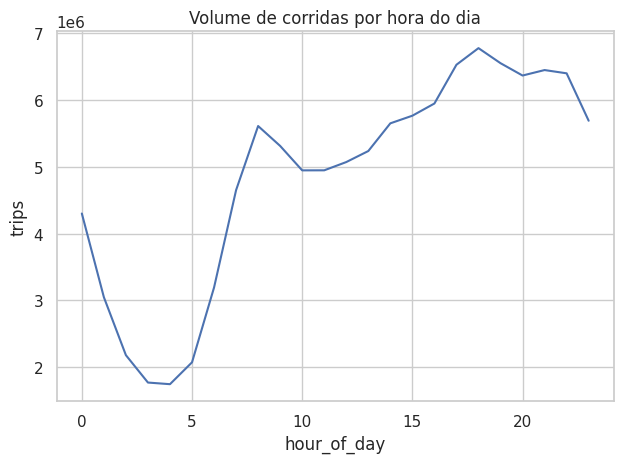

In [6]:
# Volume por hora do dia
hourly_pdf = spark.sql("""
SELECT hour_of_day, COUNT(*) AS trips
FROM trips_raw
GROUP BY 1 ORDER BY 1
""").toPandas()

ax = sns.lineplot(data=hourly_pdf, x='hour_of_day', y='trips')
ax.set_title('Volume de corridas por hora do dia')
ax.figure.tight_layout()
plt.show()


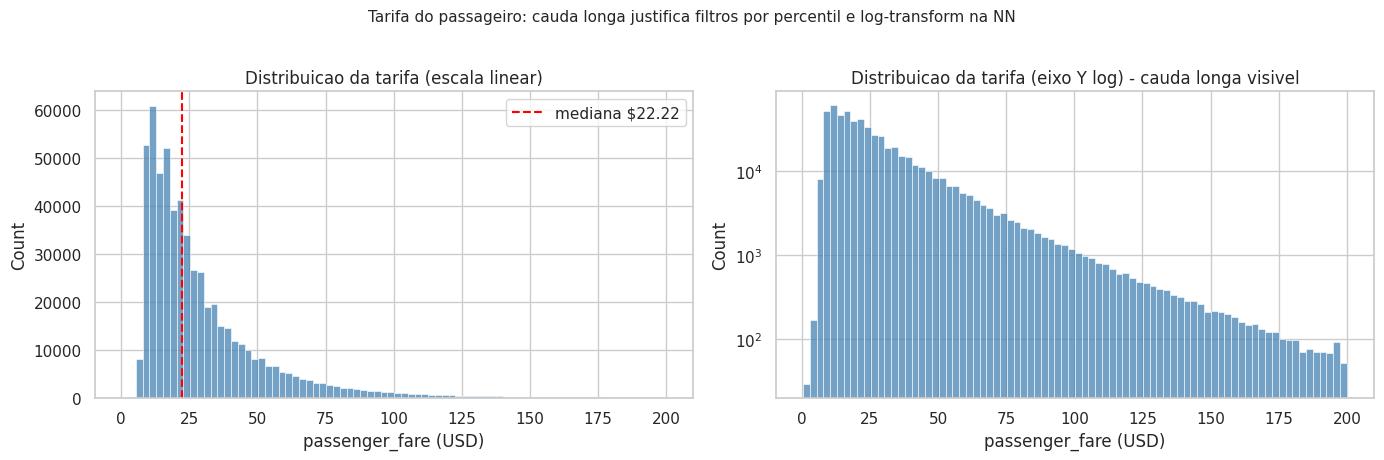

In [7]:
# Distribuicao do target (passenger_fare) - amostra estratificada para visualizacao
fare_sample_pdf = spark.sql("""
SELECT passenger_fare
FROM trips_raw TABLESAMPLE (0.5 PERCENT)
WHERE passenger_fare > 0 AND passenger_fare < 200
""").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(fare_sample_pdf['passenger_fare'], bins=80, ax=axes[0], color='steelblue')
axes[0].axvline(fare_sample_pdf['passenger_fare'].median(), color='red', linestyle='--',
                label=f"mediana ${fare_sample_pdf['passenger_fare'].median():.2f}")
axes[0].set_title('Distribuicao da tarifa (escala linear)')
axes[0].set_xlabel('passenger_fare (USD)')
axes[0].legend()

# Painel direito: mesmo histograma com Y em log para evidenciar a cauda longa.
# Nota: log_scale=(False, True) do seaborn falha em algumas versoes; usar set_yscale.
sns.histplot(fare_sample_pdf['passenger_fare'], bins=80, ax=axes[1], color='steelblue')
axes[1].set_yscale('log')
axes[1].set_title('Distribuicao da tarifa (eixo Y log) - cauda longa visivel')
axes[1].set_xlabel('passenger_fare (USD)')

fig.suptitle('Tarifa do passageiro: cauda longa justifica filtros por percentil e log-transform na NN',
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


## 3. Padrões temporais

Curva horária do volume e da tarifa média/mediana, e heatmap (dia da semana × hora). Justifica features como `is_rush_hour`, `is_late_night` e `is_weekend` no notebook de preprocessamento.

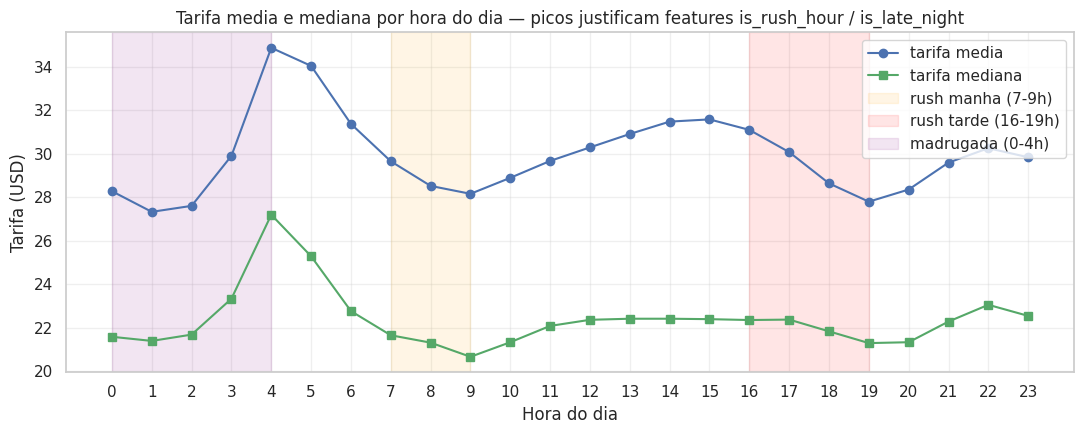

In [8]:

# Tarifa media e mediana por hora do dia
fare_hour_pdf = spark.sql("""
SELECT
    hour_of_day,
    AVG(passenger_fare)              AS avg_fare,
    PERCENTILE_APPROX(passenger_fare, 0.5) AS median_fare,
    COUNT(*)                         AS trips
FROM trips_raw
WHERE passenger_fare > 0 AND passenger_fare < 200
GROUP BY hour_of_day
ORDER BY hour_of_day
""").toPandas()

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(fare_hour_pdf['hour_of_day'], fare_hour_pdf['avg_fare'],
         marker='o', color='C0', label='tarifa media')
ax1.plot(fare_hour_pdf['hour_of_day'], fare_hour_pdf['median_fare'],
         marker='s', color='C2', label='tarifa mediana')
ax1.axvspan(7, 9, alpha=0.10, color='orange', label='rush manha (7-9h)')
ax1.axvspan(16, 19, alpha=0.10, color='red', label='rush tarde (16-19h)')
ax1.axvspan(0, 4, alpha=0.10, color='purple', label='madrugada (0-4h)')
ax1.set_xlabel('Hora do dia')
ax1.set_ylabel('Tarifa (USD)')
ax1.set_title('Tarifa media e mediana por hora do dia — picos justificam features is_rush_hour / is_late_night')
ax1.set_xticks(range(0, 24))
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)
fig.tight_layout()
plt.show()


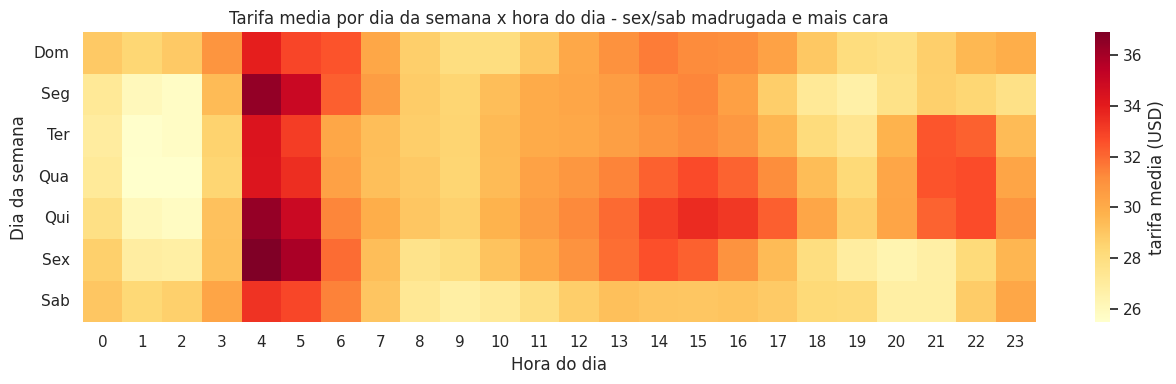

In [9]:
# Heatmap: tarifa media por (dia da semana x hora do dia)
heat_pdf = spark.sql("""
SELECT
    DAYOFWEEK(date) AS dow,        -- 1=domingo, 7=sabado
    hour_of_day,
    AVG(passenger_fare) AS avg_fare
FROM trips_raw
WHERE passenger_fare > 0 AND passenger_fare < 200
GROUP BY 1, 2
""").toPandas()

dow_labels = {1: 'Dom', 2: 'Seg', 3: 'Ter', 4: 'Qua', 5: 'Qui', 6: 'Sex', 7: 'Sab'}
heat_pdf['dow_label'] = heat_pdf['dow'].map(dow_labels)
ordered_days = ['Dom', 'Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab']
pivot = heat_pdf.pivot(index='dow_label', columns='hour_of_day', values='avg_fare')
pivot = pivot.reindex(ordered_days)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, cbar_kws={'label': 'tarifa media (USD)'},
            ax=ax, yticklabels=ordered_days)
# Forca os ticks no centro de cada celula (workaround para bug seaborn 0.13 + matplotlib 3.9)
ax.set_yticks([i + 0.5 for i in range(len(ordered_days))])
ax.set_yticklabels(ordered_days, rotation=0)
ax.set_title('Tarifa media por dia da semana x hora do dia - sex/sab madrugada e mais cara')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Dia da semana')
fig.tight_layout()
plt.show()


## 4. Operadora (Uber × Lyft)

Comparação direta entre as duas operadoras presentes no dataset (Juno/Via ausentes nesta redistribuição). Boxplots por bucket de distância mostram que as duas têm perfis similares na mediana mas divergem na cauda — útil para validar `business` como feature categórica.

/tmp/ipykernel_163/188903765.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=biz_sample_pdf, x='business', y='passenger_fare',


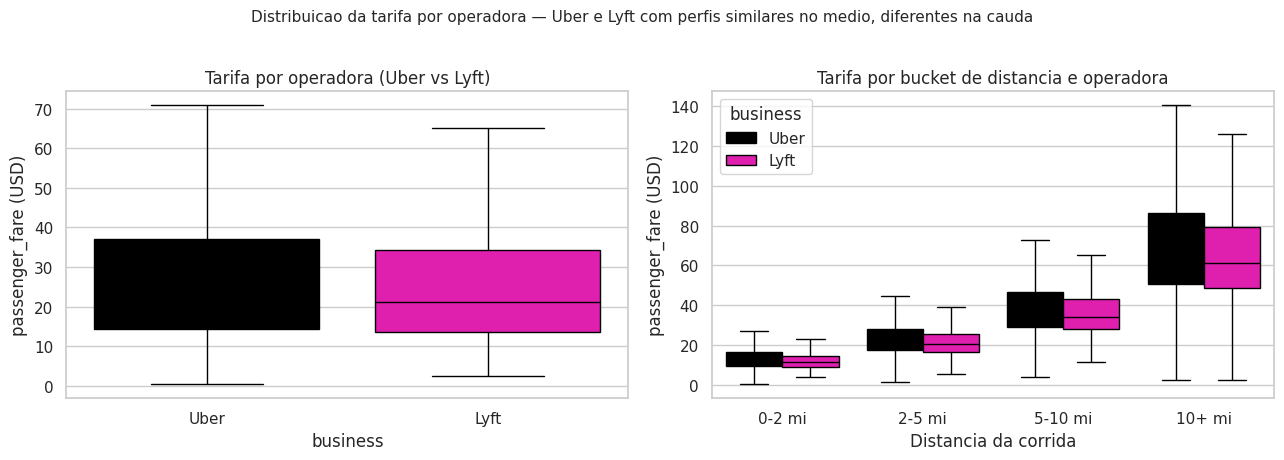

In [10]:

# Boxplot: distribuicao de tarifa por operadora (Uber vs Lyft)
biz_sample_pdf = spark.sql("""
SELECT business, passenger_fare, trip_length
FROM trips_raw TABLESAMPLE (0.5 PERCENT)
WHERE passenger_fare > 0 AND passenger_fare < 150
""").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=biz_sample_pdf, x='business', y='passenger_fare',
            ax=axes[0], palette={'Uber': '#000000', 'Lyft': '#FF00BF'}, showfliers=False)
axes[0].set_title('Tarifa por operadora (Uber vs Lyft)')
axes[0].set_ylabel('passenger_fare (USD)')

biz_sample_pdf['miles_bucket'] = pd.cut(biz_sample_pdf['trip_length'],
                                        bins=[0, 2, 5, 10, 100],
                                        labels=['0-2 mi', '2-5 mi', '5-10 mi', '10+ mi'])
sns.boxplot(data=biz_sample_pdf, x='miles_bucket', y='passenger_fare', hue='business',
            ax=axes[1], palette={'Uber': '#000000', 'Lyft': '#FF00BF'}, showfliers=False)
axes[1].set_title('Tarifa por bucket de distancia e operadora')
axes[1].set_ylabel('passenger_fare (USD)')
axes[1].set_xlabel('Distancia da corrida')

fig.suptitle('Distribuicao da tarifa por operadora — Uber e Lyft com perfis similares no medio, diferentes na cauda',
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


## 5. Padrões geográficos

Zonas de embarque mais movimentadas, fluxo OD por borough e ticket médio por borough. Confirma que pickup/dropoff borough carregam sinal forte sobre o target — entram como categóricas em todos os modelos. Zonas 264/265 (Unknown / Outside NYC) excluídas de qualquer análise geográfica.

In [11]:
# Top 10 zonas de embarque (excluindo Unknown 264/265)
top_pickups_pdf = spark.sql("""
SELECT
    z.Zone, z.Borough, COUNT(*) AS trips
FROM trips_raw t
LEFT JOIN taxi_zone_lookup z ON t.pickup_location = z.LocationID
WHERE t.pickup_location NOT IN (264, 265)
GROUP BY z.Zone, z.Borough
ORDER BY trips DESC
LIMIT 10
""").toPandas()
print(top_pickups_pdf.to_string(index=False))


                     Zone   Borough   trips
              JFK Airport    Queens 2254657
        LaGuardia Airport    Queens 2237090
             East Village Manhattan 1632149
      Crown Heights North  Brooklyn 1531409
           Midtown Center Manhattan 1457938
Times Sq/Theatre District Manhattan 1450370
     TriBeCa/Civic Center Manhattan 1350337
             East Chelsea Manhattan 1338815
            Midtown South Manhattan 1291369
West Chelsea/Hudson Yards Manhattan 1280985


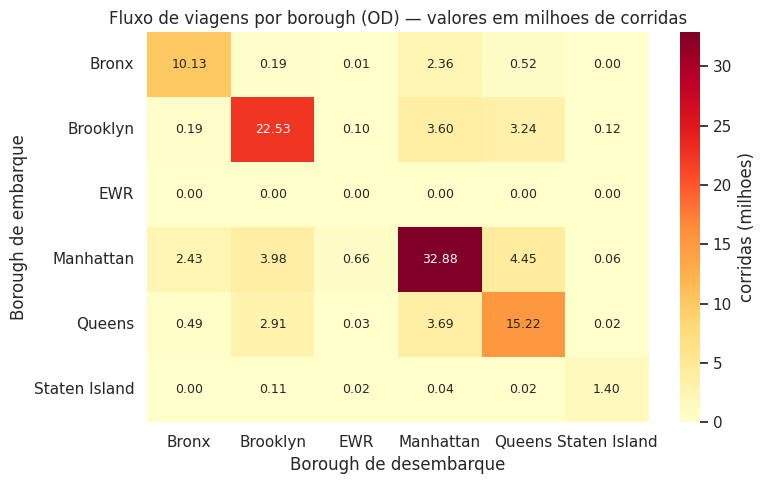

In [12]:
# Matriz OD por borough (volumes em milhoes)
borough_od_pdf = spark.sql("""
SELECT
    pu.Borough AS pu_borough,
    do.Borough AS do_borough,
    COUNT(*) AS trips
FROM trips_raw t
LEFT JOIN taxi_zone_lookup pu ON t.pickup_location  = pu.LocationID
LEFT JOIN taxi_zone_lookup do ON t.dropoff_location = do.LocationID
WHERE t.pickup_location  NOT IN (264, 265)
  AND t.dropoff_location NOT IN (264, 265)
GROUP BY 1, 2
ORDER BY 3 DESC
""").toPandas()

pivot = borough_od_pdf.pivot(index='pu_borough', columns='do_borough', values='trips').fillna(0)
pivot_m = pivot / 1_000_000  # milhoes
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_m, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'corridas (milhoes)'}, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Fluxo de viagens por borough (OD) — valores em milhoes de corridas')
ax.set_xlabel('Borough de desembarque')
ax.set_ylabel('Borough de embarque')
fig.tight_layout()
plt.show()


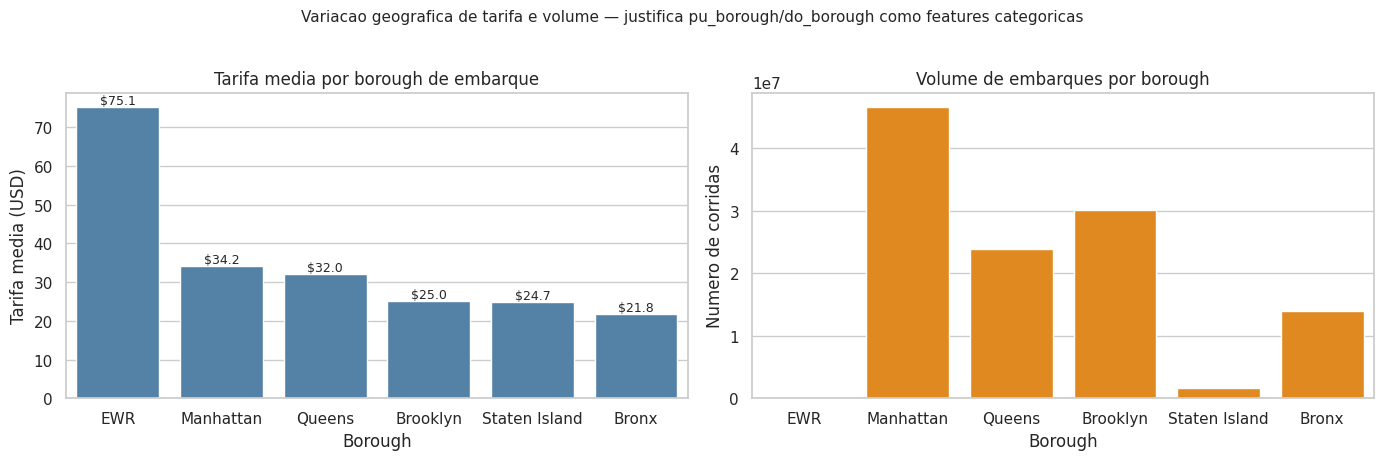

In [13]:

# Tarifa media e volume por borough de embarque
borough_pdf = spark.sql("""
SELECT
    pu.Borough AS pu_borough,
    AVG(passenger_fare) AS avg_fare,
    PERCENTILE_APPROX(passenger_fare, 0.5) AS median_fare,
    AVG(trip_length)    AS avg_miles,
    COUNT(*)            AS trips
FROM trips_raw t
LEFT JOIN taxi_zone_lookup pu ON t.pickup_location = pu.LocationID
WHERE t.pickup_location NOT IN (264, 265)
  AND t.passenger_fare > 0 AND t.passenger_fare < 200
GROUP BY pu.Borough
ORDER BY avg_fare DESC
""").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=borough_pdf, x='pu_borough', y='avg_fare', ax=axes[0],
            color='steelblue')
axes[0].set_title('Tarifa media por borough de embarque')
axes[0].set_ylabel('Tarifa media (USD)')
axes[0].set_xlabel('Borough')
for i, row in borough_pdf.iterrows():
    axes[0].text(i, row['avg_fare'], f"${row['avg_fare']:.1f}",
                 ha='center', va='bottom', fontsize=9)

sns.barplot(data=borough_pdf, x='pu_borough', y='trips', ax=axes[1],
            color='darkorange')
axes[1].set_title('Volume de embarques por borough')
axes[1].set_ylabel('Numero de corridas')
axes[1].set_xlabel('Borough')

fig.suptitle('Variacao geografica de tarifa e volume — justifica pu_borough/do_borough como features categoricas',
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()


## 6. Relação features ↔ target

Hexbin de tarifa × distância e correlações de Pearson entre features numéricas e o `passenger_fare`. A linha de referência $4 + $2/mi explicita o quanto a estrutura é aproximadamente linear, com dispersão vertical causada por surge e tarifas fixas de aeroporto. `driver_total_pay` tem correlação ~0,95 com o target por construção regulatória (TLC LL150/2018) — não usar como feature.

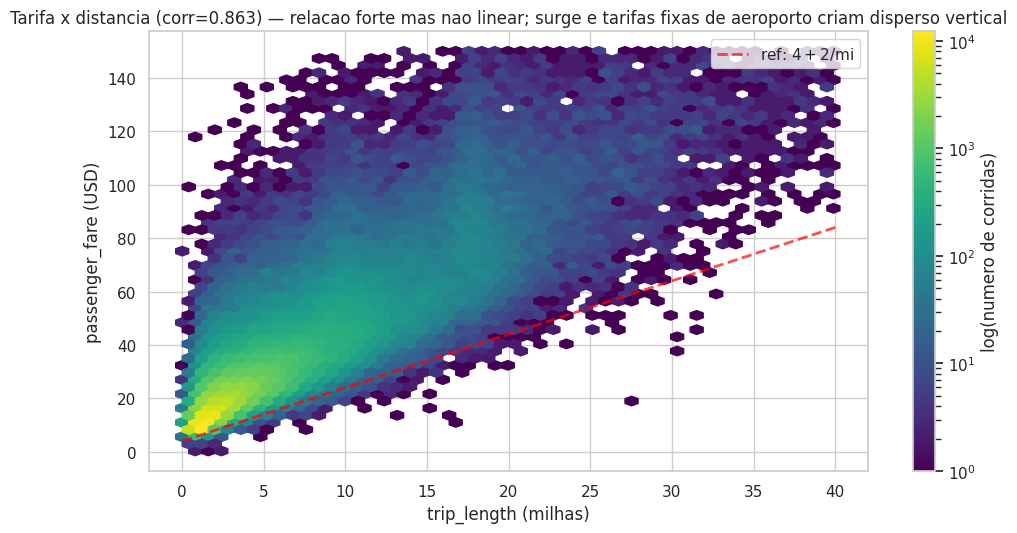

In [14]:

# Hexbin: relacao trip_length x passenger_fare (densidade)
import numpy as np
scatter_pdf = spark.sql("""
SELECT trip_length, passenger_fare
FROM trips_raw TABLESAMPLE (0.2 PERCENT)
WHERE passenger_fare > 0 AND passenger_fare < 150
  AND trip_length > 0 AND trip_length < 40
""").toPandas()

fig, ax = plt.subplots(figsize=(10, 5.5))
hb = ax.hexbin(scatter_pdf['trip_length'], scatter_pdf['passenger_fare'],
               gridsize=50, bins='log', cmap='viridis', mincnt=1)
fig.colorbar(hb, ax=ax, label='log(numero de corridas)')

# Linha de referencia: tarifa linear hipotetica $4 base + $2/milha
xs = np.linspace(0, 40, 100)
ax.plot(xs, 4 + 2 * xs, color='red', linestyle='--', linewidth=2, alpha=0.7,
        label='ref: $4 + $2/mi')

ax.set_xlabel('trip_length (milhas)')
ax.set_ylabel('passenger_fare (USD)')
ax.set_title(f'Tarifa x distancia (corr={scatter_pdf.corr().iloc[0,1]:.3f}) — relacao forte mas nao linear; surge e tarifas fixas de aeroporto criam disperso vertical')
ax.legend()
fig.tight_layout()
plt.show()


In [15]:
# Correlacao das features numericas com o target
spark.sql("""
SELECT
    ROUND(corr(trip_length,     passenger_fare), 4) AS corr_miles_fare,
    ROUND(corr(total_ride_time, passenger_fare), 4) AS corr_time_fare,
    ROUND(corr(request_to_pickup, passenger_fare), 4) AS corr_wait_fare,
    ROUND(corr(hour_of_day,     passenger_fare), 4) AS corr_hour_fare,
    ROUND(corr(driver_total_pay, passenger_fare), 4) AS corr_driver_fare
FROM trips_raw
WHERE passenger_fare > 0
""").show()
# Nota: corr(driver_total_pay, fare) alto e esperado (regulatorio), nao usar driver_total_pay como feature.


+---------------+--------------+--------------+--------------+----------------+
|corr_miles_fare|corr_time_fare|corr_wait_fare|corr_hour_fare|corr_driver_fare|
+---------------+--------------+--------------+--------------+----------------+
|         0.8785|        0.8216|         0.048|        0.0047|          0.9523|
+---------------+--------------+--------------+--------------+----------------+



## Observacoes EDA

- Dataset cobre apenas Uber e Lyft (sem Juno/Via).
- `hourly_rate` e `dollars_per_mile` sao derivadas de `passenger_fare` — excluidas do dataset preparado.
- `driver_total_pay` tem correlacao alta com o target por ser regulatorio (TLC LL150/2018) — excluido das features.
- Zonas 264 e 265 (Unknown/Outside NYC) excluidas das analises geograficas.


In [16]:
spark.stop()
